In [ ]:
#1. What are the main motivations for reducing a dataset’s
#dimensionality? What are the main drawbacks?

# Motivations
# One of the main motivations for reducing a datasets dimentionality is to reduce the number of features of a complex dataset
# Another important motivation of PCA is to find linear combinations of features and to understand the variance of your data
# It is easier to visualize complex data

# Drawbacks
# - PCA assumes features linearly distributed along dimensions and some times we do not have 
# - Loss of information
# - data oversimplification

#2. What is the curse of dimensionality?
# The curse of dimentionality is when we have millions of features for each training instance, making training 
# extremely slow and harder to find a good solution

#3. Once a dataset’s dimensionality has been reduced, is it possible to
#reverse the operation? If so, how? If not, why?

# yes PCA is basically doing a singular value decomposition (SVD) of the observational matrix (training matrix)
#, the svd transforms this matrix in three other matrices: U E and V (eigenvectors) 


#X_centered = X - X.mean(axis=0)
#U, s, Vt = np.alinalg.svd(X_centered)
#W2 = Vt[:2].T # two first components
#X2D = X_centered* W2

#Based on inverse transformation
#Recovered = X2D * W2.T

# If we perform t-sne / LLE / we are unable to recover the original data, because these methods look at neighrest neighbors, 
 # it only preserves the variance of the data without really mantaining the data points that could recover the data, 
 # because the metric of optimization is neighbouring distance

#4. Can PCA be used to reduce the dimensionality of a highly
#nonlinear dataset?
#PCA is a linear dimensionality reduction method that projects data onto orthogonal directions maximizing variance.
#Because it assumes linear structure, it performs poorly on highly nonlinear datasets (e.g., manifolds like a Swiss roll), 
#where it cannot preserve the intrinsic geometry, it assumes that featurs are evenly distributed across dimensions, which is not necessarily the case for non linear datasets. 
# In such cases, nonlinear methods like kernel PCA, UMAP, 
#or autoencoders are more appropriate.

In [4]:
#5. Suppose you perform PCA on a 1,000-dimensional dataset, setting
#the explained variance ratio to 95%. How many dimensions will
#the resulting dataset have?

#The number of dimensions is data-dependent. It is the minimum number of
#principal components needed to explain 95% of the variance, 
#so it cannot be determined without knowing the variance distribution.

import numpy as np
from sklearn.decomposition import PCA

X = np.random.rand(1000, 1000)

pca = PCA(n_components=0.95)  # keep 95% variance
X_reduced = pca.fit_transform(X)

print(pca.n_components_)  # <-- THIS is your answer




610


In [ ]:
#6. In what cases would you use vanilla PCA, Incremental PCA,
#Randomized PCA, or random projection?

# regular/vanilla PCA -> Dataset fits in memory
# -> You want exact principal components
# -> Dimensionality is moderate (not huge)

# incremental PCA -> when training set is so large that it cannot fit it in memory when computing PCA (mini batches of PCA are conducted to handle memory issues)

# Randomized PCA -> when you want to compute quickly an approximation of the d principal components, more interested in run time and less about accuracy

# random projection -> used when you want to PRESERVE THE DISTANCE between instances, when distance matters, 
# nearest neighbor search
# clustering (k-NN, k-means initialization)
# similarity-based retrieval systems



In [ ]:
#7. How can you evaluate the performance of a dimensionality
# reduction algorithm on your dataset?

# You can validate your model performance by looking at it with a specific number of PCs, full dataset, and so on
# basically by doing a grid search to see what combination of parametrs best fit our data
# if we are dealing with a classification problem we can use random forest specificallly RandomizedSearchCV to find a good 
# combinations of hyperparameters for both the pca and the random forest classifier
# if we are dealing with linear model we can use SGDClassifier function from sklearn

1. Reconstruction error (unsupervised evaluation)

If the goal is to preserve information, measure how well you can reconstruct the original data:

Reconstruction Error=∣∣X−X recovered∣∣
Lower = better
Common for PCA and autoencoders

2. Explained variance (for PCA specifically)
Look at cumulative explained variance ratio
Choose number of components that retain, e.g., 95%

3. Downstream task performance (what you mentioned 👍)
If dimensionality reduction is a preprocessing step, evaluate based on the final task:
Classification → accuracy, F1
Regression → RMSE
Clustering → silhouette score

In [ ]:
# 8. Does it make any sense to chain two different dimensionality
# reduction algorithms?

# PCA -> t-SNE
# PCA -> LLE

# lle preserves the neighbouring information and with PCA you just remove unecessary features
# reducing noise with PCA and improving speed to the next chain of dimension reduction 

In [14]:
#9. Load the MNIST dataset (introduced in Chapter 3) and split it into
#a training set and a test set (take the first 60,000 instances for
#training, and the remaining 10,000 for testing). Train a Random
#Forest classifier on the dataset and time how long it takes, then
#evaluate the resulting model on the test set. Next, use PCA to
#reduce the dataset’s dimensionality, with an explained variance
#ratio of 95%. Train a new Random Forest classifier on the
#reduced dataset and see how long it takes. Was training much
#faster? Next, evaluate the classifier on the test set. How does it
#compare to the previous classifier?

from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score
import time

mnist = fetch_openml('mnist_784', version=1)

X_train, y_train = mnist.data[:60_000], mnist.target[:60_000]
X_test, y_test = mnist.data[60_000:], mnist.target[60_000:]

clf = RandomForestClassifier(random_state=42)

start = time.perf_counter()

clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

end = time.perf_counter()

print("Elapsed time:", end - start, "seconds")







Accuracy: 0.9691
Elapsed time: 30.206752874999438 seconds


In [13]:
### PCA part
start = time.perf_counter()
pca = PCA(n_components=.95)
X_reduced = pca.fit_transform(X_train)
X_test_reduced = pca.transform(X_test)   # IMPORTANT

clf.fit(X_reduced, y_train)

y_pred = clf.predict(X_test_reduced)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy for reduced X:", accuracy)

end = time.perf_counter()

print("Elapsed time for reduced X:", end - start, "seconds")

Accuracy for reduced X: 0.9487
Elapsed time for reduced X: 88.95462195900018 seconds


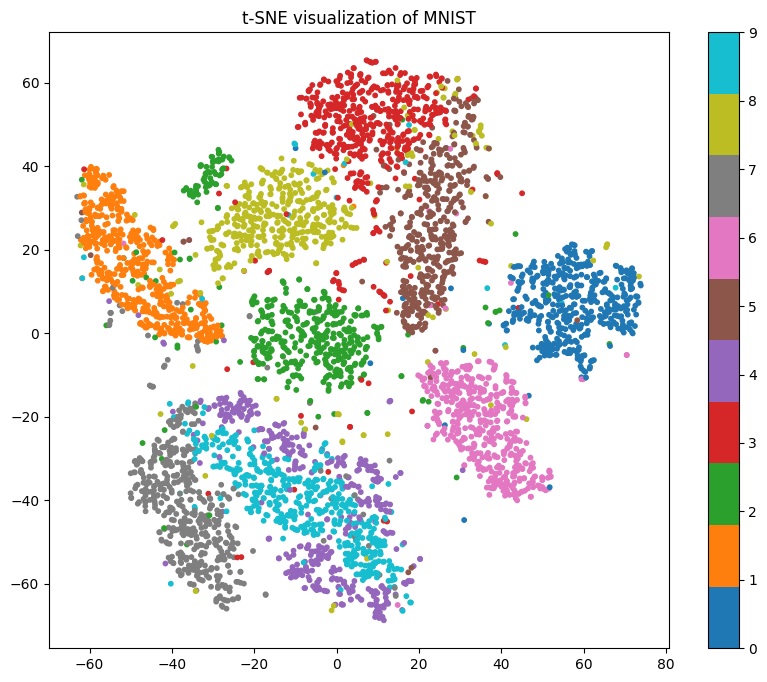

In [12]:
#10. Use t-SNE to reduce the MNIST dataset down to two dimensions
#and plot the result using Matplotlib. You can use a scatterplot
#using 10 different colors to represent each image’s target class.
#Alternatively, you can replace each dot in the scatterplot with the
#corresponding instance’s class (a digit from 0 to 9), or even plot
#scaled-down versions of the digit images themselves (if you plot
#all digits, the visualization will be too cluttered, so you should
#either draw a random sample or plot an instance only if no other
#instance has already been plotted at a close distance). You should
#get a nice visualization with well-separated clusters of digits. Try
#using other dimensionality reduction algorithms such as PCA,
#LLE, or MDS and compare the resulting visualizations.


from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml("mnist_784", version=1, as_frame=False)

X = mnist.data
y = mnist.target.astype(int)


np.random.seed(42)

idx = np.random.choice(len(X), 5000, replace=False)
X_sample = X[idx]
y_sample = y[idx] # 0, 1,2,3,4,5,6,7,8,9

from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_2d = tsne.fit_transform(X_sample)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10
)

plt.colorbar(scatter)
plt.title("t-SNE visualization of MNIST")
plt.show()


